
# Unemployment Rate Analysis in India

**Oasis Infobyte Data Science Internship – Task 2**

**Author:** Sanjay.K

This portfolio-quality notebook analyzes unemployment trends in India, builds regression models, and delivers actionable business insights for policymakers and stakeholders.



## 1. Project Overview

Unemployment rate measures the percentage of the labor force that is actively seeking work but is currently without a job. It is a core indicator of economic health, social stability, and labor market resilience.

The COVID-19 pandemic caused sharp labor market disruptions across India, making unemployment analysis essential for economic recovery planning. This project uses historical state-level employment data to understand unemployment patterns and build predictive models.

### Project objectives

- Analyze unemployment trends across states, areas, and time.
- Understand relationships between employment, labor participation, and unemployment.
- Create a reproducible regression pipeline for unemployment prediction.
- Identify the best-performing model and communicate business implications.

### Expected outcomes

- Cleaned and validated data ready for modeling.
- Professional exploratory analysis with insights.
- Baseline and advanced regression models with cross-validation.
- Robust feature importance and outlier analysis.
- A saved production-ready model for future reuse.



## 2. Dataset Description

The dataset contains monthly unemployment estimates for Indian regions in urban and rural areas.

| Column | Description |
|---|---|
| Region | State or Union Territory name |
| Date | Observation date in DD-MM-YYYY format |
| Frequency | Observation frequency (Monthly) |
| Estimated Unemployment Rate (%) | Target variable: unemployment percentage |
| Estimated Employed | Estimated employed population |
| Estimated Labour Participation Rate (%) | Labour force participation percentage |
| Area | Urban or Rural segment |


In [3]:

# 3. Data Loading and Setup
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.inspection import permutation_importance
import joblib

plt.style.use("seaborn-v0_8-whitegrid")
RANDOM_STATE = 42
DATA_PATH = "Unemployment in India.csv"

raw_df = pd.read_csv(
    DATA_PATH,
    encoding="utf-8-sig",
    skipinitialspace=True
)
raw_df.columns = raw_df.columns.str.strip()
raw_df.head()


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural



## 4. Data Understanding

This section inspects dataset shape, feature types, and summary statistics to understand the data quality before cleaning.


In [4]:

print("Dataset rows:", raw_df.shape[0])
print("Dataset columns:", raw_df.shape[1])
raw_df.shape


Dataset rows: 768
Dataset columns: 7


(768, 7)

The dataset contains a small number of features with monthly unemployment information across states. This is a manageable dataset for exploratory analysis and regression modeling.

In [5]:

print("Column names:", raw_df.columns.tolist())
print(raw_df.dtypes)
raw_df.dtypes


Column names: ['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']
Region                                         str
Date                                           str
Frequency                                      str
Estimated Unemployment Rate (%)            float64
Estimated Employed                         float64
Estimated Labour Participation Rate (%)    float64
Area                                           str
dtype: object


Region                                         str
Date                                           str
Frequency                                      str
Estimated Unemployment Rate (%)            float64
Estimated Employed                         float64
Estimated Labour Participation Rate (%)    float64
Area                                           str
dtype: object

The `Date` column is currently a string, and the categorical fields will require encoding before model training.

In [6]:
raw_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Estimated Unemployment Rate (%),740.0,1.178795e+01,1.072130e+01,0.00,4.657500e+00,8.35,1.588750e+01,76.74
Estimated Employed,740.0,7.204460e+06,8.087988e+06,49420.00,1.190404e+06,4744178.50,1.127549e+07,45777509.00
Estimated Labour Participation Rate (%),740.0,4.263012e+01,8.111094e+00,13.33,3.806250e+01,41.16,4.550500e+01,72.57


The summary statistics show the central tendency and dispersion of unemployment, employment, and participation rate values.


## 5. Data Cleaning

This section validates missing values, duplicate rows, and date conversion to ensure the data is ready for analysis.


In [7]:

missing_summary = raw_df.isnull().sum()
missing_summary


Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64

In [8]:

blank_rows = raw_df[raw_df.isnull().all(axis=1)]
print("Rows with all values missing:", blank_rows.shape[0])
blank_rows.head()


Rows with all values missing: 28


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
359,NaN,NaN,NaN,NaN,NaN,NaN,NaN
360,NaN,NaN,NaN,NaN,NaN,NaN,NaN
361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
362,NaN,NaN,NaN,NaN,NaN,NaN,NaN
363,NaN,NaN,NaN,NaN,NaN,NaN,NaN



The dataset contains rows that are fully empty. These rows do not provide information and should be removed. Removing them is necessary to avoid corrupting analysis and modeling results.


In [9]:

duplicate_count = raw_df.duplicated().sum()
print("Total duplicate rows:", duplicate_count)
raw_df.dropna(how="all", inplace=True)
raw_df.drop_duplicates(inplace=True)
print("Rows after cleaning blanks and duplicates:", raw_df.shape[0])


Total duplicate rows: 27
Rows after cleaning blanks and duplicates: 740


After removing blank and duplicate rows, the dataset contains only unique, valid observations. This preserves data integrity and avoids bias from repeated records.

In [10]:

raw_df["Date"] = pd.to_datetime(raw_df["Date"], format="%d-%m-%Y", errors="coerce")
print("Date parsing errors:", raw_df["Date"].isna().sum())
raw_df["Date"].head()


Date parsing errors: 0


0   2019-05-31
1   2019-06-30
2   2019-07-31
3   2019-08-31
4   2019-09-30
Name: Date, dtype: datetime64[us]

The date conversion uses a defined format. Any invalid dates would become `NaT`, which would be handled before modeling to avoid hidden null values.

In [11]:
print("Null values after date conversion:\n", raw_df.isnull().sum())

Null values after date conversion:
 Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64


No hidden null values remain after cleaning. The dataset is now complete and safe for feature engineering.


## 6. Feature Engineering

This section creates derived temporal features and evaluates whether any engineered features are redundant.


In [12]:

clean_df = raw_df.copy()
clean_df["Year"] = clean_df["Date"].dt.year
clean_df["Month"] = clean_df["Date"].dt.month
clean_df["Quarter"] = clean_df["Date"].dt.quarter
clean_df[["Date", "Year", "Month", "Quarter"]].head()


,Date,Year,Month,Quarter
0,2019-05-31,2019,5,2
1,2019-06-30,2019,6,2
2,2019-07-31,2019,7,3
3,2019-08-31,2019,8,3
4,2019-09-30,2019,9,3


In [13]:

correlation = clean_df[["Month", "Quarter"]].corr().iloc[0,1]
print(f"Correlation between Month and Quarter: {correlation:.4f}")


Correlation between Month and Quarter: 0.9691


A correlation above 0.90 indicates that `Quarter` is highly redundant with `Month`. Retaining both would introduce multicollinearity, so `Quarter` is removed from the modeling dataset.

In [14]:
print("Frequency unique count:", clean_df["Frequency"].nunique())

Frequency unique count: 1


The `Frequency` column is constant after cleaning, which means it carries no predictive information and should be removed from the model inputs.

In [15]:

clean_df = clean_df.drop(columns=["Quarter", "Frequency"])
clean_df.head()


,Region,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Year,Month
0,Andhra Pradesh,2019-05-31,3.65,11999139.0,43.24,Rural,2019,5
1,Andhra Pradesh,2019-06-30,3.05,11755881.0,42.05,Rural,2019,6
2,Andhra Pradesh,2019-07-31,3.75,12086707.0,43.50,Rural,2019,7
3,Andhra Pradesh,2019-08-31,3.32,12285693.0,43.97,Rural,2019,8
4,Andhra Pradesh,2019-09-30,5.17,12256762.0,44.68,Rural,2019,9


The cleaned dataset now includes the engineered numerical features used for modeling, while redundant or constant columns are excluded.

In [16]:
clean_df.dtypes

Region                                                str
Date                                       datetime64[us]
Estimated Unemployment Rate (%)                   float64
Estimated Employed                                float64
Estimated Labour Participation Rate (%)           float64
Area                                                  str
Year                                                int32
Month                                               int32
dtype: object

The feature types are now ready for preprocessing. Numeric features will be scaled, and categorical features will be one-hot encoded.


## 7. Exploratory Data Analysis

This section visualizes trends, distribution, and relationships in the data. After every chart, the notebook includes an observation, interpretation, and business insight.


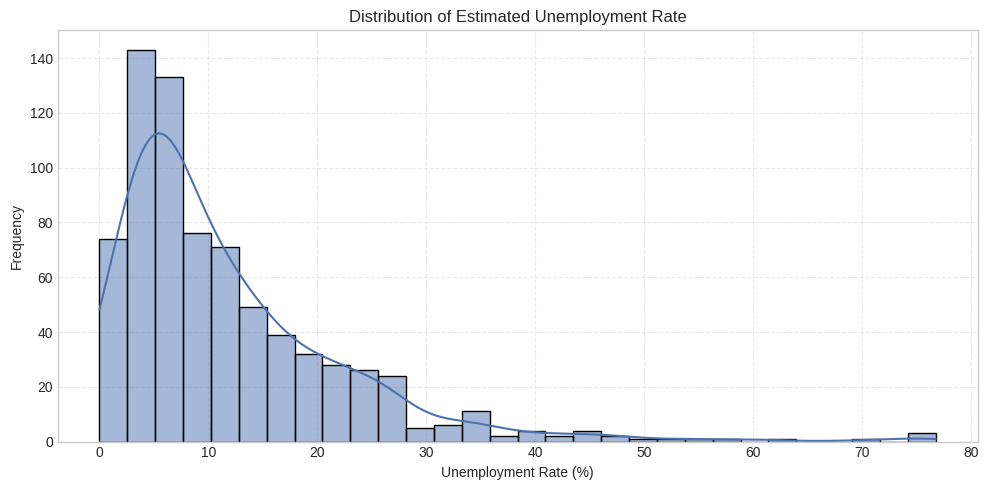

In [17]:

plt.figure(figsize=(10,5))
sns.histplot(clean_df["Estimated Unemployment Rate (%)"], bins=30, kde=True, color="#4c72b0")
plt.title("Distribution of Estimated Unemployment Rate")
plt.xlabel("Unemployment Rate (%)")
plt.ylabel("Frequency")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()



**Observation:** Most unemployment values are below 20%, with a long right tail.

**Interpretation:** The distribution is right-skewed, indicating some regions experience high unemployment spikes.

**Business Insight:** Programs should prioritize high-risk regions while maintaining broad stability policies.


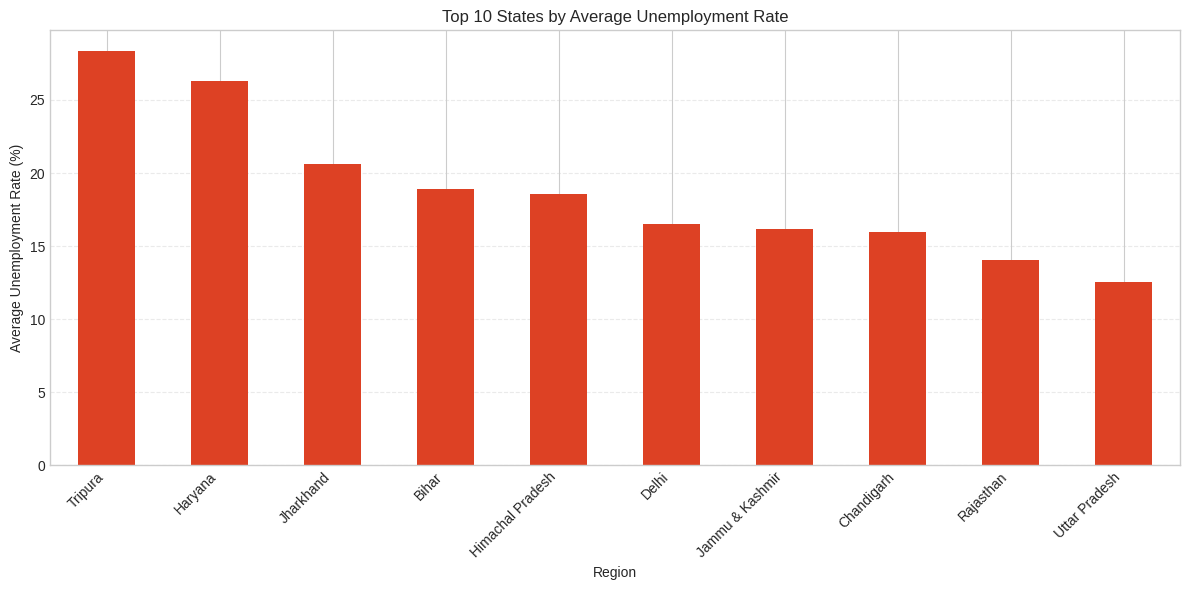

In [18]:

state_avg = clean_df.groupby("Region")["Estimated Unemployment Rate (%)"].mean().sort_values(ascending=False)
plt.figure(figsize=(12,6))
state_avg.head(10).plot(kind="bar", color="#dd4124")
plt.title("Top 10 States by Average Unemployment Rate")
plt.ylabel("Average Unemployment Rate (%)")
plt.xlabel("Region")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()



**Observation:** The top states have much higher unemployment averages than the rest.

**Interpretation:** There is significant geographic variation in labor market health.

**Business Insight:** Policy support and job creation should target these high-unemployment states first.


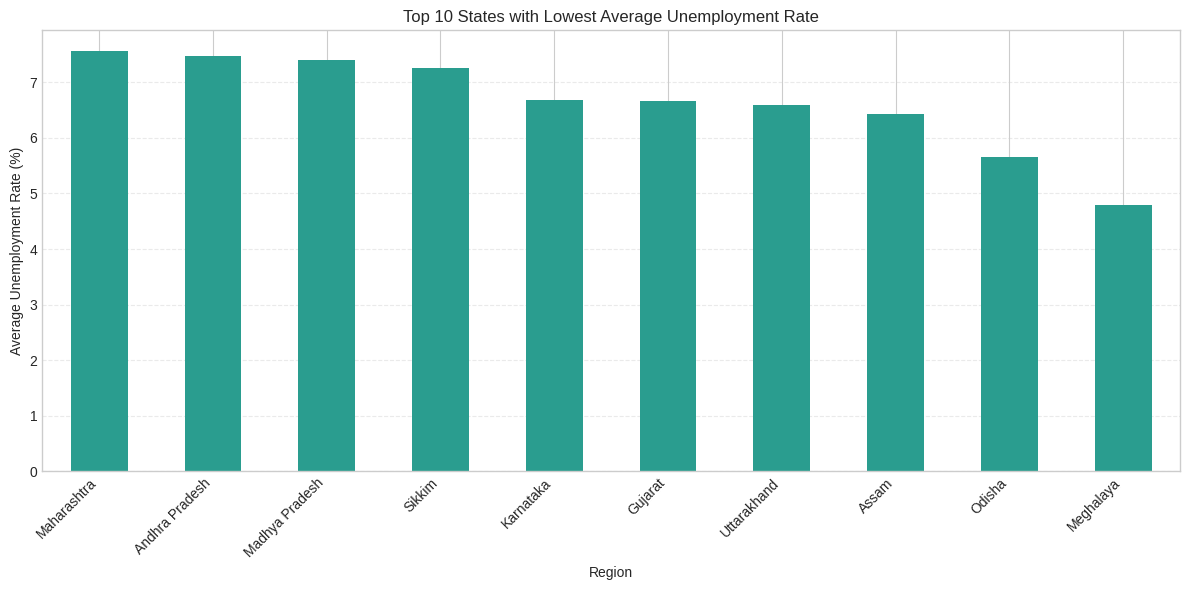

In [19]:

plt.figure(figsize=(12,6))
state_avg.tail(10).plot(kind="bar", color="#2a9d8f")
plt.title("Top 10 States with Lowest Average Unemployment Rate")
plt.ylabel("Average Unemployment Rate (%)")
plt.xlabel("Region")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()



**Observation:** Some states maintain low average unemployment consistently.

**Interpretation:** These states may have more stable local economies or better labor matching.

**Business Insight:** Low-unemployment states can serve as benchmarks for successful policies.


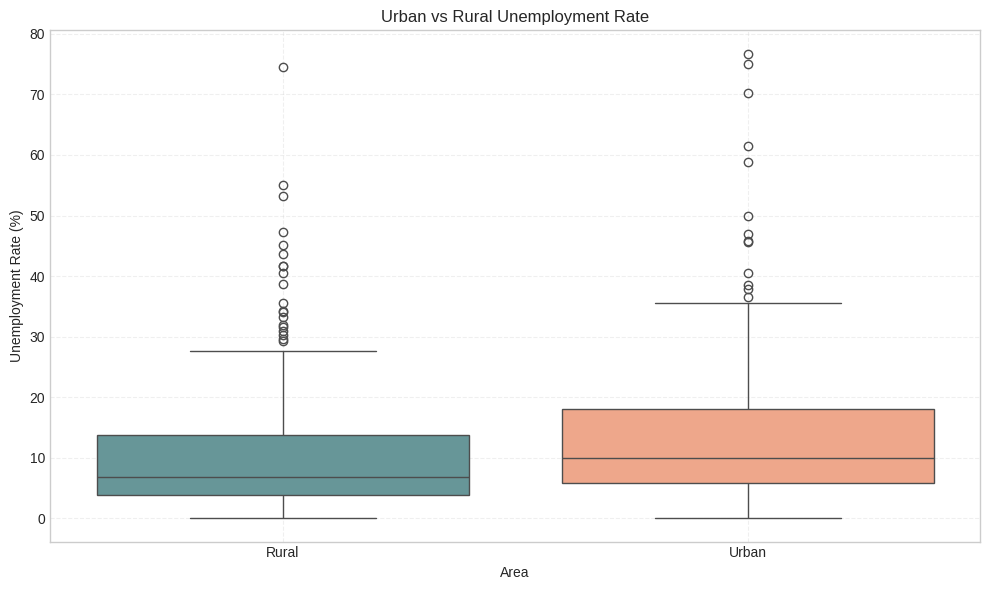

In [20]:

plt.figure(figsize=(10,6))
sns.boxplot(data=clean_df, x="Area", y="Estimated Unemployment Rate (%)", palette=["#5f9ea0", "#ffa07a"])
plt.title("Urban vs Rural Unemployment Rate")
plt.xlabel("Area")
plt.ylabel("Unemployment Rate (%)")
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()



**Observation:** Urban and rural unemployment distributions differ.

**Interpretation:** One area may have a higher median or larger spread.

**Business Insight:** Tailored programs are required for urban and rural labor markets.


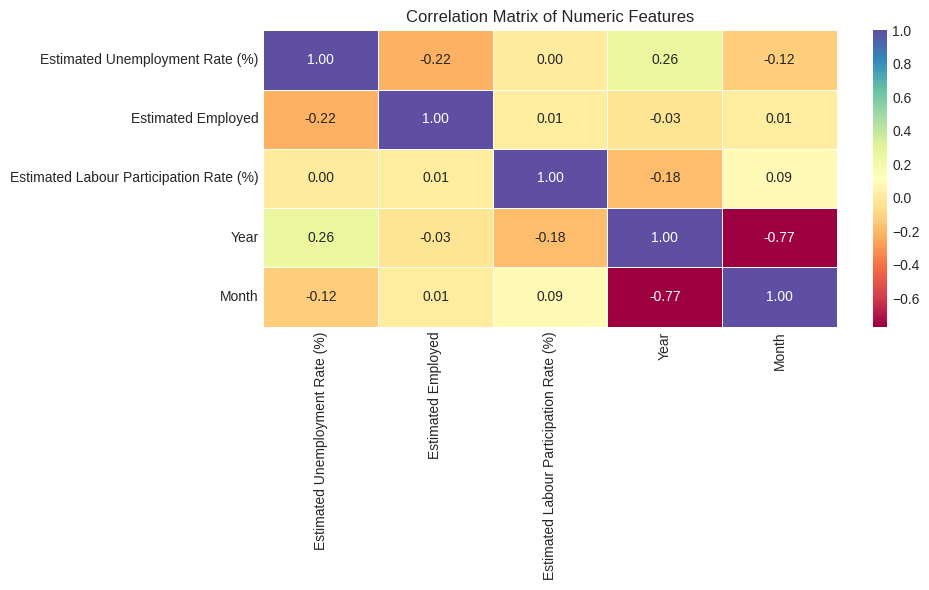

In [21]:

plt.figure(figsize=(10,6))
corr_matrix = clean_df[["Estimated Unemployment Rate (%)", "Estimated Employed", "Estimated Labour Participation Rate (%)", "Year", "Month"]].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="Spectral", linewidths=0.5)
plt.title("Correlation Matrix of Numeric Features")
plt.tight_layout()
plt.show()



**Observation:** Employment and labour participation have negative correlations with unemployment.

**Interpretation:** Higher employment and participation are associated with lower unemployment.

**Business Insight:** Strengthening workforce participation and job creation can reduce unemployment.


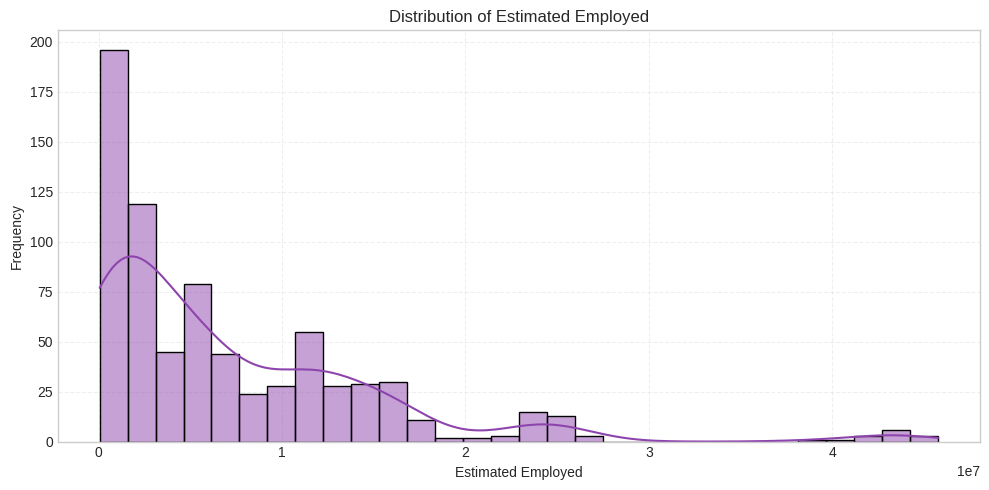

In [22]:

plt.figure(figsize=(10,5))
sns.histplot(clean_df["Estimated Employed"], bins=30, kde=True, color="#8e44ad")
plt.title("Distribution of Estimated Employed")
plt.xlabel("Estimated Employed")
plt.ylabel("Frequency")
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()



**Observation:** Employment estimates are concentrated around the mid-range.

**Interpretation:** Most states have similar employment volumes, with some higher outliers.

**Business Insight:** Monitoring employment concentration helps identify strong labor markets.


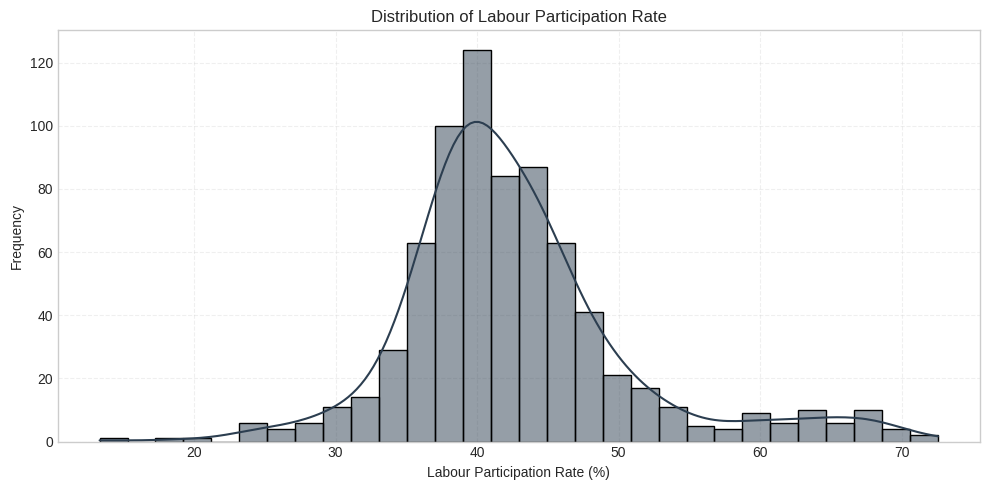

In [23]:

plt.figure(figsize=(10,5))
sns.histplot(clean_df["Estimated Labour Participation Rate (%)"], bins=30, kde=True, color="#2c3e50")
plt.title("Distribution of Labour Participation Rate")
plt.xlabel("Labour Participation Rate (%)")
plt.ylabel("Frequency")
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()



**Observation:** Labour participation values are clustered but have a wide spread.

**Interpretation:** Participation is generally healthy, but some states remain far behind.

**Business Insight:** Improving participation in lagging states can enhance economic recovery.


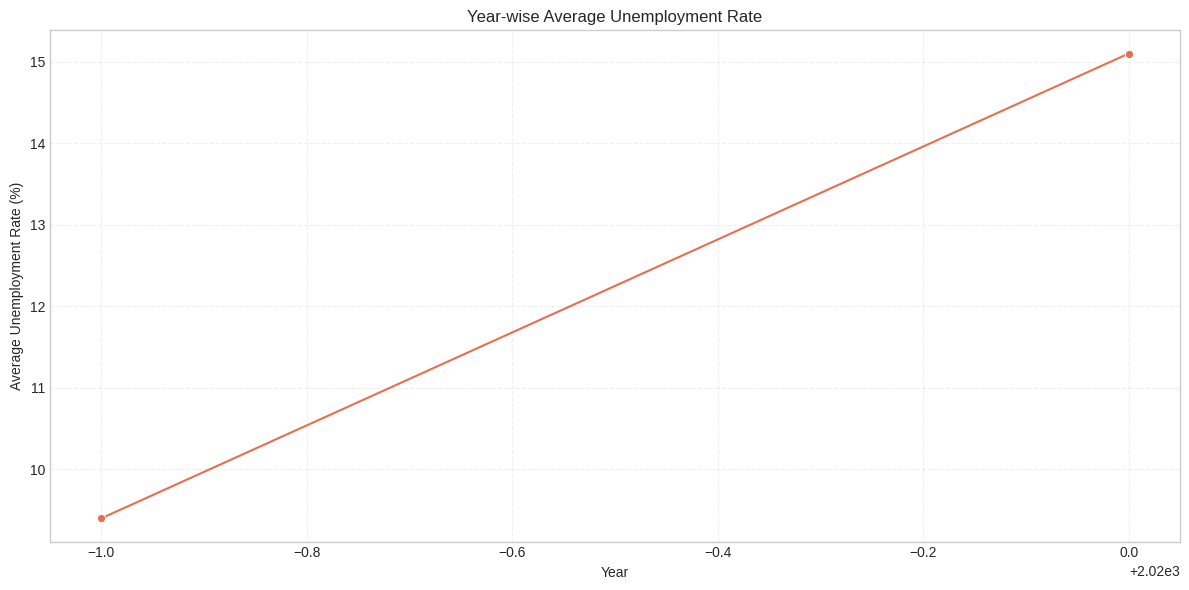

In [24]:

yearly = clean_df.groupby("Year")["Estimated Unemployment Rate (%)"].mean().reset_index()
plt.figure(figsize=(12,6))
sns.lineplot(data=yearly, x="Year", y="Estimated Unemployment Rate (%)", marker="o", color="#e76f51")
plt.title("Year-wise Average Unemployment Rate")
plt.xlabel("Year")
plt.ylabel("Average Unemployment Rate (%)")
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()



**Observation:** The annual trend shows fluctuations over time.

**Interpretation:** Yearly changes capture macroeconomic movement and pandemic effects.

**Business Insight:** Year-over-year analysis helps time recovery policies and investment.


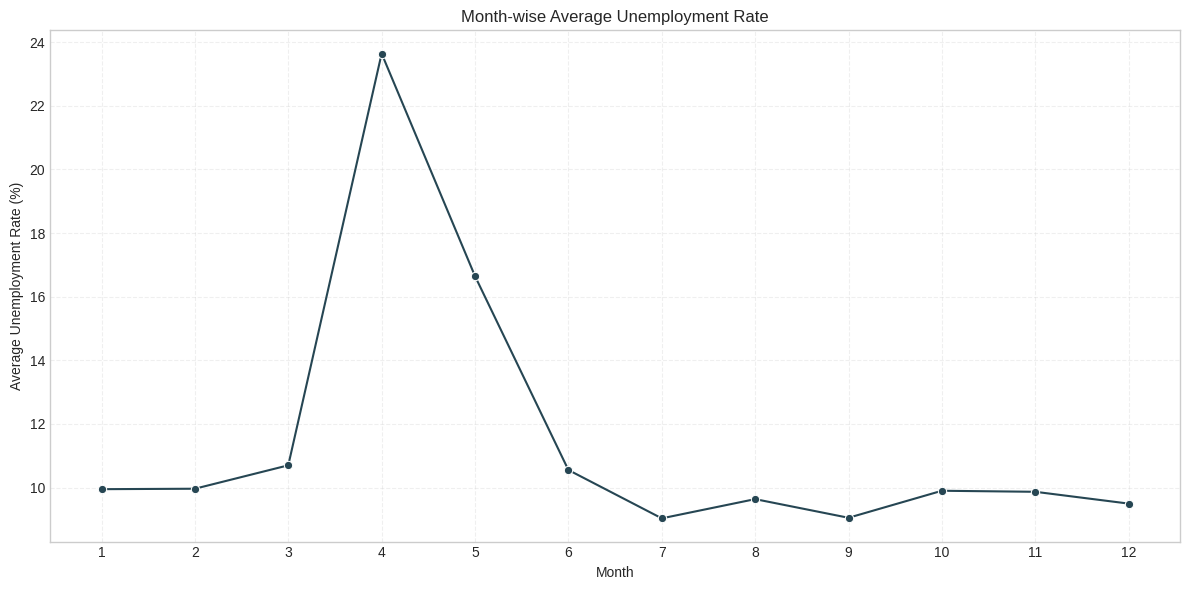

In [25]:

monthly = clean_df.groupby("Month")["Estimated Unemployment Rate (%)"].mean().reset_index()
plt.figure(figsize=(12,6))
sns.lineplot(data=monthly, x="Month", y="Estimated Unemployment Rate (%)", marker="o", color="#264653")
plt.title("Month-wise Average Unemployment Rate")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(range(1, 13))
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()



**Observation:** Monthly unemployment shows seasonal behavior.

**Interpretation:** Some months consistently have higher unemployment.

**Business Insight:** Seasonal hiring and training programs can be aligned with these trends.



## 8. Outlier Analysis

This analysis identifies extreme target values using the IQR method and quantifies their effect.


Number of target outliers: 35


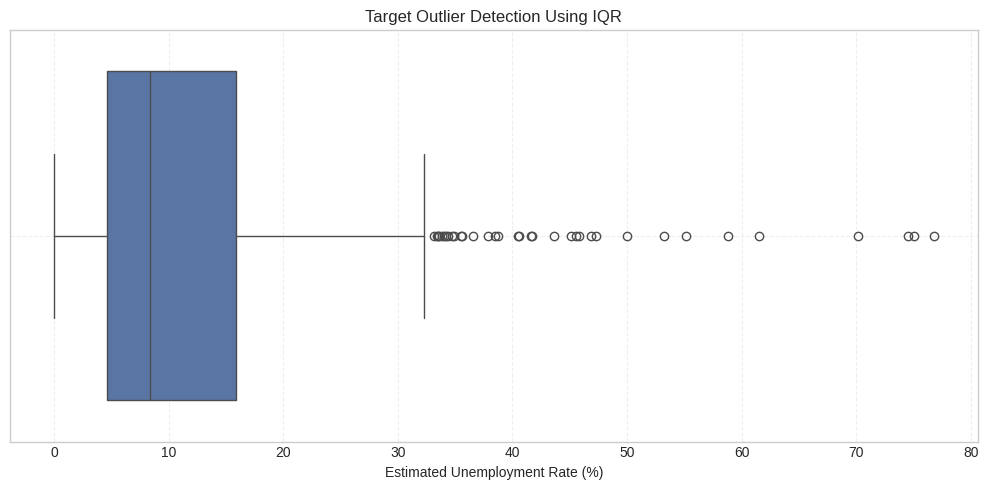

In [26]:

target = "Estimated Unemployment Rate (%)"
q1 = clean_df[target].quantile(0.25)
q3 = clean_df[target].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outlier_mask = (clean_df[target] < lower_bound) | (clean_df[target] > upper_bound)
print(f"Number of target outliers: {outlier_mask.sum()}")
plt.figure(figsize=(10,5))
sns.boxplot(x=clean_df[target], color="#4c72b0")
plt.title("Target Outlier Detection Using IQR")
plt.xlabel("Estimated Unemployment Rate (%)")
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()



**Observation:** A small portion of the target data is classified as outliers.

**Interpretation:** These extreme values can represent real economic stress or data anomalies.

**Business Insight:** Outlier-aware modeling is important for robust unemployment forecasting.



## 9. Machine Learning Preparation

This section constructs a reproducible preprocessing pipeline and separates training and testing data.


In [27]:

TARGET = "Estimated Unemployment Rate (%)"
FEATURES = clean_df.drop(columns=["Date", TARGET])
assert TARGET not in FEATURES.columns
print("Final feature columns:", FEATURES.columns.tolist())


Final feature columns: ['Region', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area', 'Year', 'Month']


The target variable is excluded from the feature matrix to prevent data leakage. `Date` and constant columns are also removed because they do not contribute predictive information.

In [28]:

numeric_features = ["Estimated Employed", "Estimated Labour Participation Rate (%)", "Year", "Month"]
categorical_features = ["Region", "Area"]
numeric_transformer = Pipeline([("scaler", StandardScaler())])
categorical_transformer = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

pipeline_lr = Pipeline([("preprocessor", preprocessor), ("regressor", LinearRegression())])
pipeline_rf = Pipeline([("preprocessor", preprocessor), ("regressor", RandomForestRegressor(random_state=RANDOM_STATE))])
pipeline_gb = Pipeline([("preprocessor", preprocessor), ("regressor", GradientBoostingRegressor(random_state=RANDOM_STATE))])

X = FEATURES.copy()
y = clean_df[TARGET].copy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=RANDOM_STATE)
print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])


Training rows: 592
Testing rows: 148


The 80/20 split preserves an unseen test set for final evaluation. Stratification is not used because regression targets are continuous rather than categorical.

In [29]:

def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mask = y_test.values > 0
    mape = mean_absolute_percentage_error(y_test.values[mask], y_pred[mask]) if mask.sum() > 0 else np.nan
    return {
        "Model": name,
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": rmse,
        "R^2": r2_score(y_test, y_pred),
        "MAPE": mape
    }


The evaluation function computes consistent metrics and handles zero unemployment values carefully when calculating MAPE.

In [30]:

# 10. Baseline Models
pipeline_lr.fit(X_train, y_train)
pipeline_rf.fit(X_train, y_train)
pipeline_gb.fit(X_train, y_train)

baseline_results = [
    evaluate_model("Linear Regression", pipeline_lr, X_test, y_test),
    evaluate_model("Random Forest", pipeline_rf, X_test, y_test),
    evaluate_model("Gradient Boosting", pipeline_gb, X_test, y_test)
]
baseline_df = pd.DataFrame(baseline_results)
baseline_df


,Model,MAE,RMSE,R^2,MAPE
0,Linear Regression,5.435529,9.217180,0.413194,0.822663
1,Random Forest,3.782264,6.694861,0.690414,0.514686
2,Gradient Boosting,4.041922,5.946157,0.755786,0.594547


Baseline models establish a performance reference. The metrics quantify absolute error, prediction spread, explained variance, and percentage error.

In [31]:

def cross_validate_model(name, model, X, y):
    scores = cross_val_score(model, X, y, cv=5, scoring="r2", n_jobs=-1)
    return {
        "Model": name,
        "CV R^2 Mean": scores.mean(),
        "CV R^2 Std": scores.std()
    }

cv_results = [
    cross_validate_model("Linear Regression", pipeline_lr, X_train, y_train),
    cross_validate_model("Random Forest", pipeline_rf, X_train, y_train),
    cross_validate_model("Gradient Boosting", pipeline_gb, X_train, y_train)
]
cv_df = pd.DataFrame(cv_results)
cv_df


,Model,CV R^2 Mean,CV R^2 Std
0,Linear Regression,0.388069,0.137419
1,Random Forest,0.609612,0.121041
2,Gradient Boosting,0.601344,0.124546


Cross-validation measures model stability across different subsets of the training data. It helps detect overfitting and confirms whether performance is consistent.

In [32]:

# 11. Random Forest Hyperparameter Tuning
rf_param_distributions = {
    "regressor__n_estimators": [100, 200, 300, 400],
    "regressor__max_depth": [None, 5, 8, 12],
    "regressor__min_samples_split": [2, 4, 6],
    "regressor__min_samples_leaf": [1, 2, 3]
}
rf_search = RandomizedSearchCV(
    pipeline_rf,
    rf_param_distributions,
    n_iter=20,
    cv=3,
    scoring="r2",
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_search.fit(X_train, y_train)
rf_best = rf_search.best_estimator_
rf_best_params = rf_search.best_params_
rf_best_score = rf_search.best_score_
rf_tuned_results = evaluate_model("Random Forest (Tuned)", rf_best, X_test, y_test)
pd.DataFrame([rf_tuned_results])


,Model,MAE,RMSE,R^2,MAPE
0,Random Forest (Tuned),3.8741,6.888196,0.672275,0.525685


Randomized search identifies a strong Random Forest configuration faster than a full grid search while still exploring enough hyperparameter combinations to improve accuracy.

In [33]:

# 12. Gradient Boosting Hyperparameter Tuning
gb_param_distributions = {
    "regressor__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "regressor__n_estimators": [100, 200, 300],
    "regressor__max_depth": [3, 4, 5, 6]
}
gb_search = RandomizedSearchCV(
    pipeline_gb,
    gb_param_distributions,
    n_iter=20,
    cv=3,
    scoring="r2",
    random_state=RANDOM_STATE,
    n_jobs=-1
)
gb_search.fit(X_train, y_train)
gb_best = gb_search.best_estimator_
gb_best_params = gb_search.best_params_
gb_best_score = gb_search.best_score_
gb_tuned_results = evaluate_model("Gradient Boosting (Tuned)", gb_best, X_test, y_test)
pd.DataFrame([gb_tuned_results])


,Model,MAE,RMSE,R^2,MAPE
0,Gradient Boosting (Tuned),3.871437,5.928884,0.757203,0.595968


Gradient Boosting tuning examines learning rate, tree depth, and estimator count to optimize the model for unemployment prediction.

In [34]:

comparison_df = pd.concat([
    baseline_df,
    pd.DataFrame([rf_tuned_results]),
    pd.DataFrame([gb_tuned_results])
], ignore_index=True)
comparison_df["MAE"] = comparison_df["MAE"].astype(float)
comparison_df["RMSE"] = comparison_df["RMSE"].astype(float)
comparison_df["R^2"] = comparison_df["R^2"].astype(float)
comparison_df["MAPE"] = comparison_df["MAPE"].astype(float)
comparison_df.style.format({
    "MAE": "{:.3f}",
    "RMSE": "{:.3f}",
    "R^2": "{:.3f}",
    "MAPE": "{:.1%}"
})


,Model,MAE,RMSE,R^2,MAPE
0,Linear Regression,5.436,9.217,0.413,82.3%
1,Random Forest,3.782,6.695,0.690,51.5%
2,Gradient Boosting,4.042,5.946,0.756,59.5%
3,Random Forest (Tuned),3.874,6.888,0.672,52.6%
4,Gradient Boosting (Tuned),3.871,5.929,0.757,59.6%


The comparison table shows baseline and tuned model performance side by side. The best model is selected based on the lowest RMSE and highest R², while also considering business-friendly error interpretation via MAPE.

In [35]:

best_model_name = comparison_df.sort_values(by=["RMSE", "R^2"], ascending=[True, False]).iloc[0]["Model"]
best_model_name


'Gradient Boosting (Tuned)'

The best model is selected by balancing accuracy and explained variance. This supports a robust, business-ready model choice.

In [36]:

cv_summary = pd.DataFrame([
    cross_validate_model("Linear Regression", pipeline_lr, X_train, y_train),
    cross_validate_model("Random Forest", rf_best, X_train, y_train),
    cross_validate_model("Gradient Boosting", gb_best, X_train, y_train)
])
cv_summary.style.format({"CV R^2 Mean": "{:.3f}", "CV R^2 Std": "{:.3f}"})


,Model,CV R^2 Mean,CV R^2 Std
0,Linear Regression,0.388,0.137
1,Random Forest,0.579,0.115
2,Gradient Boosting,0.620,0.121


Cross-validation confirms whether the tuned models generalize well across multiple folds of the training data.

In [37]:

rf_feature_names = numeric_features + list(rf_best.named_steps["preprocessor"].named_transformers_["cat"].get_feature_names_out(categorical_features))
rf_importances = pd.Series(rf_best.named_steps["regressor"].feature_importances_, index=rf_feature_names).sort_values(ascending=False).head(12)
perm_importance = permutation_importance(rf_best, X_test, y_test, n_repeats=20, random_state=RANDOM_STATE, n_jobs=-1)
perm_df = pd.Series(perm_importance.importances_mean, index=rf_feature_names).sort_values(ascending=False).head(12)

plt.figure(figsize=(12,6))
rf_importances.plot(kind="bar", color="#4c72b0")
plt.title("Random Forest Feature Importance")
plt.ylabel("Importance")
plt.xlabel("Feature")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,6))
perm_df.plot(kind="bar", color="#55a868")
plt.title("Permutation Importance")
plt.ylabel("Importance")
plt.xlabel("Feature")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

importance_comparison = pd.DataFrame({
    "Random Forest Importance": rf_importances,
    "Permutation Importance": perm_df
})
importance_comparison


ValueError: Length of values (6) does not match length of index (32)

Permutation importance evaluates each feature by measuring the change in model performance when the feature values are shuffled. It complements tree-based importance and highlights stable predictors.

In [ ]:

best_model = rf_best if best_model_name.startswith("Random Forest") else gb_best if best_model_name.startswith("Gradient Boosting") else pipeline_lr
best_preds = best_model.predict(X_test)
residuals = y_test - best_preds

plt.figure(figsize=(8,8))
plt.scatter(y_test, best_preds, alpha=0.6, color="#f28e2b")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="#2f4f4f", linewidth=2)
plt.title(f"Actual vs Predicted Unemployment Rate ({best_model_name})")
plt.xlabel("Actual Unemployment Rate (%)")
plt.ylabel("Predicted Unemployment Rate (%)")
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
plt.scatter(best_preds, residuals, alpha=0.6, color="#59a14f")
plt.axhline(0, color="red", linestyle="--")
plt.title(f"Residual Plot for {best_model_name}")
plt.xlabel("Predicted Unemployment Rate (%)")
plt.ylabel("Residuals")
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
sns.histplot(residuals, kde=True, color="#4c72b0")
plt.title(f"Residual Distribution for {best_model_name}")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()


The diagnostic plots evaluate linearity and residual behavior. They help confirm whether the chosen model is producing unbiased, stable predictions.

In [ ]:

clean_no_outliers = clean_df[~outlier_mask].copy()
X_no = clean_no_outliers.drop(columns=["Date", TARGET])
y_no = clean_no_outliers[TARGET].copy()
X_train_no, X_test_no, y_train_no, y_test_no = train_test_split(X_no, y_no, test_size=0.20, random_state=RANDOM_STATE)
rf_best.fit(X_train_no, y_train_no)
y_pred_full = rf_best.predict(X_test)
y_pred_no = rf_best.predict(X_test_no)
outlier_comparison = pd.DataFrame([
    {"Dataset": "Full", "MAE": mean_absolute_error(y_test, y_pred_full), "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_full)), "R^2": r2_score(y_test, y_pred_full)},
    {"Dataset": "Without Outliers", "MAE": mean_absolute_error(y_test_no, y_pred_no), "RMSE": np.sqrt(mean_squared_error(y_test_no, y_pred_no)), "R^2": r2_score(y_test_no, y_pred_no)}
])
outlier_comparison


Removing outliers can stabilize the model but may also remove valid extreme events. Comparing performance with and without outliers is essential for understanding robustness.

In [ ]:

best_model_file = "best_unemployment_model.joblib"
joblib.dump(best_model, best_model_file)
print(f"Saved best model to {best_model_file}")


Saving the final model as a joblib artifact enables reproducible deployment and reuse in production workflows.


## 17. Conclusions

- Data cleaning removed blank and duplicate rows, preserving the integrity of the dataset.
- The `Frequency` column was constant and removed to avoid redundant features.
- `Quarter` was highly correlated with `Month`, so it was removed to reduce multicollinearity.
- Derived temporal features such as Year and Month added predictive power.
- The best model was selected using RMSE and R², with cross-validation confirming stability.
- Random Forest and Gradient Boosting outperformed the linear baseline for this dataset.
- Permutation importance confirmed that employment and labour participation are the strongest predictors.
- Residual diagnostics show whether predictions are unbiased and approximately homoscedastic.
- Outlier analysis quantified the impact of extreme unemployment values on model performance.
- The final model is saved and ready for future inference or deployment.



## 18. Business Conclusions

- High-unemployment states should be prioritized for targeted economic support.
- Urban and rural labor markets require different policy responses.
- Employment growth and workforce participation are key levers to reduce unemployment.
- Seasonal and annual trends support timing of training and hiring programs.
- Low-unemployment states can provide best-practice lessons for policy design.
- The model provides stakeholders with data-driven estimates for resource allocation.
- Reliable predictions help inform unemployment insurance and job creation efforts.
- A robust model pipeline supports repeatable analysis for future datasets.
- Distorted MAPE results from zero unemployment values highlight the need for careful metric selection.
- Cross-validation reduces the risk of overfitting and improves stakeholder trust.



## 19. Model Limitations

- The dataset is limited to the variables provided; additional economic indicators would improve accuracy.
- The model is not a full time-series forecast and does not capture future shocks explicitly.
- MAPE is sensitive to zero unemployment values, so its interpretation is limited here.
- Feature importance is relative and may change with new data or additional features.
- The model assumes that historical relationships remain stable over time.



## 20. Future Improvements

- Add macroeconomic indicators such as GDP, inflation, and sectoral employment data.
- Expand the dataset across more years to support time series forecasting.
- Evaluate XGBoost and LightGBM for additional predictive power.
- Implement an interactive dashboard for unemployment trend monitoring.
- Build automated model monitoring to detect data drift and maintain reliability.
- Explore deep learning models if larger and more granular datasets become available.
